<a href="https://colab.research.google.com/github/sashank1326/ML_Practice/blob/main/DL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Prog 1**

In [ ]:
import numpy as np

class perceptron:
  def __init__(self,wt,bias):
    self.wt = wt
    self.bias = bias

  def predict(self,x):
    total = np.dot(wt,x)+bias
    return step(total)
def step(x):
  return 1 if x>=0 else 0

In [ ]:
#for AnD operation
wt = np.array([1,1])
bias = -1.5
c = perceptron(wt,bias)
for x in([0,0],[1,0],[0,1],[1,1]):
  print(x,">>>",c.predict(x))

[0, 0] >>> 0
[1, 0] >>> 0
[0, 1] >>> 0
[1, 1] >>> 1


In [ ]:
#for OR operation
wt = np.array([1,1])
bias = -0.5
c = perceptron(wt,bias)
for x in([0,0],[1,0],[0,1],[1,1]):
  print(x,">>>",c.predict(x))

[0, 0] >>> 0
[1, 0] >>> 1
[0, 1] >>> 1
[1, 1] >>> 1


# **Prog2**
Examine the feasibility of implementing the XOR and XNOR (¬XOR) operations (Non linear data) using a single perceptron. If not possible, clearly explain the reason based on the concept of linear separability.

In [ ]:
import numpy as np

class Perceptron:
    def __init__(self, w, b):
        self.w = np.array(w)
        self.b = b

    def predict(self, x):
        z = np.dot(self.w, x) + self.b
        return 1 if z >= 0 else 0


# Try XOR with a single perceptron
p = Perceptron([1, 1], -0.5)

X = [(0,0), (0,1), (1,0), (1,1)]
print("Single Perceptron XOR Output:")
for x in X:
    print(x, "->", p.predict(x))


#A single perceptron can only create a linear (straight-line) decision boundary, but the XOR/XNOR data points are not linearly separable.

Single Perceptron XOR Output:
(0, 0) -> 0
(0, 1) -> 1
(1, 0) -> 1
(1, 1) -> 1


# **Prog3**

In [ ]:
# To overcome this limitation, we use a multilayer perceptron (MLP) with one or more hidden layers, which can create non-linear decision boundaries.

import numpy as np

def step(x):
  return 1 if x>=0 else 0

w_or = np.array([1,1])
b_or = -0.5

w_and = np.array([1,1])
b_and = -1.5

w_out = np.array([1,-2])
b_out = -0.5

def XOR(x):
  h1 = step(np.dot(w_or,x)+b_or)
  h2 = step(np.dot(w_and,x)+b_and)
  out = np.dot(w_out,[h1,h2])+b_out
  return step(out)

# test
X = [(0,0), (0,1), (1,0), (1,1)]
for x in X:
    print(x, "->", XOR(x))

(0, 0) -> 0
(0, 1) -> 1
(1, 0) -> 1
(1, 1) -> 0


In [ ]:
import numpy as np

def step(z):
    return 1 if z >= 0 else 0

# Hidden layer
w_or  = np.array([1, 1]);  b_or  = -0.5
w_and = np.array([1, 1]);  b_and = -1.5

# Output layer (XNOR)
w_out = np.array([-1, 2])
b_out = 0.5

def XNOR(x):
    h1 = step(np.dot(w_or, x) + b_or)      # OR
    h2 = step(np.dot(w_and, x) + b_and)    # AND
    y  = step(np.dot(w_out, [h1, h2]) + b_out)
    return y

# Test
X = [(0,0), (0,1), (1,0), (1,1)]
for x in X:
    print(x, "->", XNOR(x))


(0, 0) -> 1
(0, 1) -> 0
(1, 0) -> 0
(1, 1) -> 1


In [ ]:
import numpy as np

# -------------------------
# Perceptron Class
# -------------------------
class Perceptron:
    def __init__(self, n_inputs, weights=None, bias=None, lr=0.1):
        self.n_inputs = n_inputs
        self.lr = lr
        # initialize weights
        if weights is None:
            self.w = np.zeros(n_inputs)
        else:
            self.w = np.array(weights, dtype=float)
        # initialize bias
        self.b = 0.0 if bias is None else bias

    def predict(self, x):
        z = np.dot(self.w, x) + self.b
        return 1 if z >= 0 else 0

    def train(self, X, Y, epochs=5):
        for epoch in range(epochs):
            print(f"\nEpoch {epoch+1}")
            for x, y_true in zip(X, Y):
                y_pred = self.predict(x)
                error = y_true - y_pred
                # Weight update
                self.w += self.lr * error * x
                # Bias update
                self.b += self.lr * error
                print(f"x:{x}, y_true:{y_true}, y_pred:{y_pred}, w:{self.w}, b:{self.b}")
            print("-"*50)

# -------------------------
# Dataset (in-code)
# -------------------------
# Features: [Matt Damon, Thriller, Nolan, IMDb rating scaled 0-1]
X = np.array([
    [1,1,1,0.9],
    [0,1,0,0.7],
    [1,0,0,0.6],
    [0,0,1,0.8],
    [1,1,0,0.4],
    [0,0,0,0.3]
])

# Labels: 1=Like, 0=Dislike
Y = np.array([1,0,1,1,1,0])

# Test sample
test_sample = np.array([1,0,1,0.8])

# -------------------------
# i) MP Perceptron (weights=0, bias=0)
# -------------------------
print("=== MP Perceptron (weights=0, bias=0) ===")
mp_perceptron = Perceptron(n_inputs=4)
mp_perceptron.train(X, Y, epochs=5)
print("Test sample prediction:", mp_perceptron.predict(test_sample))

# -------------------------
# ii) Perceptron with weights only (bias=0)
# -------------------------
print("\n=== Perceptron with weights only (bias=0) ===")
initial_weights = [0.2, -0.1, 0.3, 0.5]
perceptron_w = Perceptron(n_inputs=4, weights=initial_weights, bias=0)
perceptron_w.train(X, Y, epochs=5)
print("Test sample prediction:", perceptron_w.predict(test_sample))

# -------------------------
# iii) Perceptron with weights and bias
# -------------------------
print("\n=== Perceptron with weights and bias ===")
initial_weights = [0.2, -0.1, 0.3, 0.5]
initial_bias = -0.2
perceptron_wb = Perceptron(n_inputs=4, weights=initial_weights, bias=initial_bias)
perceptron_wb.train(X, Y, epochs=5)
print("Test sample prediction:", perceptron_wb.predict(test_sample))


=== MP Perceptron (weights=0, bias=0) ===

Epoch 1
x:[1.  1.  1.  0.9], y_true:1, y_pred:1, w:[0. 0. 0. 0.], b:0.0
x:[0.  1.  0.  0.7], y_true:0, y_pred:1, w:[ 0.   -0.1   0.   -0.07], b:-0.1
x:[1.  0.  0.  0.6], y_true:1, y_pred:0, w:[ 0.1  -0.1   0.   -0.01], b:0.0
x:[0.  0.  1.  0.8], y_true:1, y_pred:0, w:[ 0.1  -0.1   0.1   0.07], b:0.1
x:[1.  1.  0.  0.4], y_true:1, y_pred:1, w:[ 0.1  -0.1   0.1   0.07], b:0.1
x:[0.  0.  0.  0.3], y_true:0, y_pred:1, w:[ 0.1  -0.1   0.1   0.04], b:0.0
--------------------------------------------------

Epoch 2
x:[1.  1.  1.  0.9], y_true:1, y_pred:1, w:[ 0.1  -0.1   0.1   0.04], b:0.0
x:[0.  1.  0.  0.7], y_true:0, y_pred:0, w:[ 0.1  -0.1   0.1   0.04], b:0.0
x:[1.  0.  0.  0.6], y_true:1, y_pred:1, w:[ 0.1  -0.1   0.1   0.04], b:0.0
x:[0.  0.  1.  0.8], y_true:1, y_pred:1, w:[ 0.1  -0.1   0.1   0.04], b:0.0
x:[1.  1.  0.  0.4], y_true:1, y_pred:1, w:[ 0.1  -0.1   0.1   0.04], b:0.0
x:[0.  0.  0.  0.3], y_true:0, y_pred:1, w:[ 0.1  -0.1   0.1   0

# **Week2**

**Implement an MLP by varying bias, weights, and learning rate, and record observations for different learning rate values. Plot a graph showing the relationship between loss (error) and learning rate.**

In [ ]:
import pandas as pd
df  = pd.read_csv("/content/drive/MyDrive/ML_LAB/titanic_train.csv")
print(df.head(5))

   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   NaN        S  


In [ ]:
# MLP for Titanic Dataset – Effect of Learning Rate on Loss

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --------------------------------------------------
# Load Dataset
# --------------------------------------------------
data = pd.read_csv("/content/drive/MyDrive/ML_LAB/titanic_train.csv")

# Drop text columns
data = data.drop(columns=["PassengerId", "Name", "Ticket", "Cabin"])

# Encode categorical variables
data["Sex"] = data["Sex"].map({"male": 0, "female": 1})
data["Embarked"] = data["Embarked"].map({"S": 0, "C": 1, "Q": 2})

# Fill missing values
data["Age"].fillna(data["Age"].mean(), inplace=True)
data["Embarked"].fillna(data["Embarked"].mode()[0], inplace=True)

# Split features and target
X = data.drop("Survived", axis=1).values
y = data["Survived"].values.reshape(-1, 1)


/tmp/ipython-input-692214551.py:20: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data["Age"].fillna(data["Age"].mean(), inplace=True)
/tmp/ipython-input-692214551.py:21: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', tr

/tmp/ipython-input-746081154.py:5: RuntimeWarning: overflow encountered in exp
  return 1 / (1 + np.exp(-x))


Learning Rate: 0.001, Final Loss: 0.146009
Learning Rate: 0.01, Final Loss: 0.182885
Learning Rate: 0.05, Final Loss: 0.223496
Learning Rate: 0.1, Final Loss: 0.214299
Learning Rate: 0.5, Final Loss: 0.616162


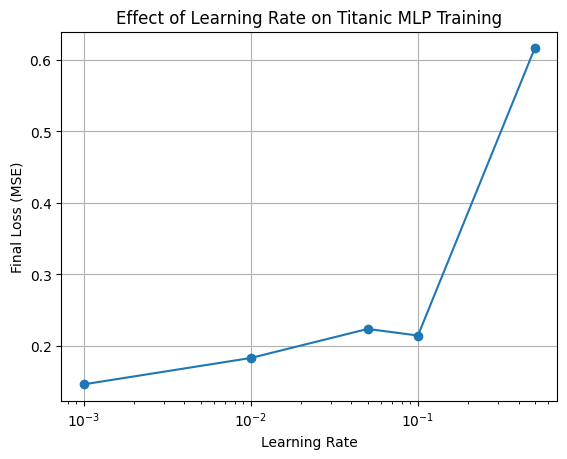

In [ ]:

# --------------------------------------------------
# Activation functions
# --------------------------------------------------
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def sigmoid_derivative(x):
    return x * (1 - x)

# --------------------------------------------------
# Learning rates to test
# --------------------------------------------------
learning_rates = [0.001,0.01, 0.05, 0.1,0.5]
final_losses = []

epochs = 10000
input_size = X.shape[1]
hidden_size = 8
output_size = 1

# --------------------------------------------------
# Train model for each learning rate
# --------------------------------------------------
for lr in learning_rates:

    np.random.seed(42)

    W1 = np.random.randn(input_size, hidden_size)
    b1 = np.zeros((1, hidden_size))

    W2 = np.random.randn(hidden_size, output_size)
    b2 = np.zeros((1, output_size))

    for epoch in range(epochs):

        # Forward pass
        hidden_input = np.dot(X, W1) + b1
        hidden_output = sigmoid(hidden_input)

        final_input = np.dot(hidden_output, W2) + b2
        y_pred = sigmoid(final_input)

        # Loss (MSE)
        error = y - y_pred
        loss = np.mean(error ** 2)

        # Backpropagation
        d_output = error * sigmoid_derivative(y_pred)
        d_hidden = d_output.dot(W2.T) * sigmoid_derivative(hidden_output)

        # Update
        W2 += hidden_output.T.dot(d_output) * lr
        b2 += np.sum(d_output, axis=0, keepdims=True) * lr

        W1 += X.T.dot(d_hidden) * lr
        b1 += np.sum(d_hidden, axis=0, keepdims=True) * lr

    final_losses.append(loss)
    print(f"Learning Rate: {lr}, Final Loss: {loss:.6f}")

# --------------------------------------------------
# Plot
# --------------------------------------------------
plt.figure()
plt.plot(learning_rates, final_losses, marker='o')
plt.xscale("log")
plt.xlabel("Learning Rate")
plt.ylabel("Final Loss (MSE)")
plt.title("Effect of Learning Rate on Titanic MLP Training")
plt.grid(True)
plt.show()


**Implement a Perceptron on IRIS Dataset what are your observations with respect to learning rate using Perceptron class in sklearn. (explore all the parameters of Perceptron class).**


Learning Rate Analysis

LR=0.0001 | Train=0.8286 | Test=0.7556 | Iter=6
LR=0.001  | Train=0.8286 | Test=0.7556 | Iter=6
LR=0.01   | Train=0.8857 | Test=0.8000 | Iter=13
LR=0.1    | Train=0.8857 | Test=0.8000 | Iter=13
LR=1.0    | Train=0.8857 | Test=0.8000 | Iter=13


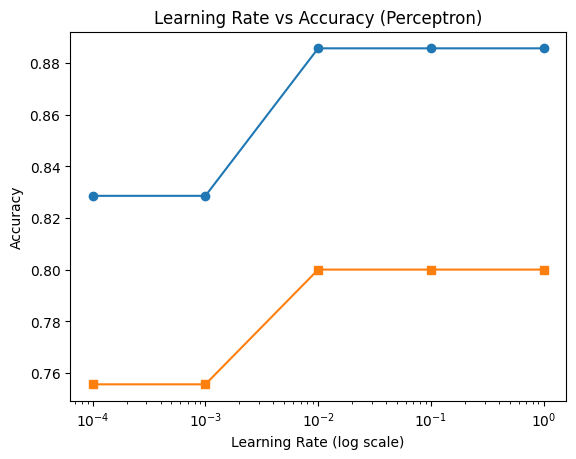

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Perceptron
from sklearn.metrics import accuracy_score

# Load IRIS dataset
data = load_iris()
X = data.data
y = data.target

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# Feature Scaling (VERY IMPORTANT for Perceptron)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Different learning rates
learning_rates = [0.0001, 0.001, 0.01, 0.1, 1.0]

train_accuracies = []
test_accuracies = []
iterations_taken = []

print("\nLearning Rate Analysis\n")

for lr in learning_rates:
    model = Perceptron(
        penalty=None,            # No regularization
        alpha=0.0001,            # Used only if penalty is set
        eta0=lr,                 # Learning rate
        max_iter=2000,           # Max epochs
        tol=1e-4,                # Stopping tolerance
        fit_intercept=True,
        shuffle=True,
        early_stopping=False,
        random_state=42
    )

    model.fit(X_train, y_train)

    # Predictions
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    # Accuracy
    train_acc = accuracy_score(y_train, y_train_pred)
    test_acc = accuracy_score(y_test, y_test_pred)

    train_accuracies.append(train_acc)
    test_accuracies.append(test_acc)
    iterations_taken.append(model.n_iter_)

    print(f"LR={lr:<6} | Train={train_acc:.4f} | Test={test_acc:.4f} | Iter={model.n_iter_}")

# Plot Results
plt.figure()
plt.plot(learning_rates, train_accuracies, marker='o')
plt.plot(learning_rates, test_accuracies, marker='s')
plt.xscale('log')
plt.xlabel("Learning Rate (log scale)")
plt.ylabel("Accuracy")
plt.title("Learning Rate vs Accuracy (Perceptron)")
plt.show()


**Implement MLP on any dataset and explore what particular parameters works for it such as learning rate, iterations etc**

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score


df = pd.read_csv("/content/drive/MyDrive/ML_LAB/titanic_train.csv")


X = df[['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare']]
y = df['Survived']


X['Sex'] = LabelEncoder().fit_transform(X['Sex'])


X['Age'].fillna(X['Age'].median(), inplace=True)
X['Fare'].fillna(X['Fare'].median(), inplace=True)

/tmp/ipython-input-2931395831.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X['Sex'] = LabelEncoder().fit_transform(X['Sex'])
/tmp/ipython-input-2931395831.py:18: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  X['Age'].fillna(X['Age'].median(), inplace=True)
/tmp/ipython-input-2931

MLP Accuracy on Titanic: 0.8134328358208955


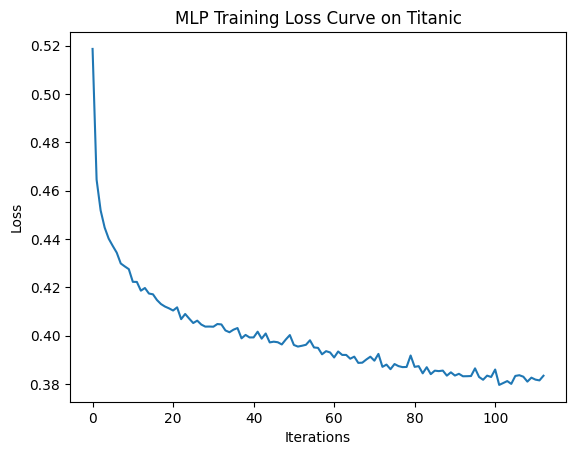

In [ ]:

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

mlp = MLPClassifier(
    hidden_layer_sizes=(10,),
    activation='tanh',
    solver='adam',
    learning_rate_init=0.01,
    batch_size=32,
    max_iter=200,
)

# Train
mlp.fit(X_train, y_train)

# Predict
y_pred = mlp.predict(X_test)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)
print("MLP Accuracy on Titanic:", accuracy)

# Plot loss curve
import matplotlib.pyplot as plt
plt.plot(mlp.loss_curve_)
plt.xlabel("Iterations")
plt.ylabel("Loss")
plt.title("MLP Training Loss Curve on Titanic")
plt.show()


**Implement the MLP using the Types of GD (BGD,SGD,Mini BatchGD, SGD with Momentum, SGD with Nesterov,Adagrad, RMSProp,Adadelta and Adam) for learning XOR operation.Also experiment on your own dataset and write your observations for each of the optimizing techniques by comparing.**

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import SGD
# Load dataset
df = pd.read_csv("/content/drive/MyDrive/ML_LAB/titanic_train.csv")

# Select important features
df = df[['Survived','Pclass','Sex','Age','SibSp','Parch','Fare','Embarked']]

# Handle missing values
df['Age'].fillna(df['Age'].mean(), inplace=True)
df['Embarked'].fillna(df['Embarked'].mode()[0], inplace=True)

# Convert categorical to numeric
df['Sex'] = df['Sex'].map({'male':0, 'female':1})
df = pd.get_dummies(df, columns=['Embarked'], drop_first=True)

# Split features & target
X = df.drop('Survived', axis=1).values
y = df['Survived'].values.reshape(-1,1)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Feature Scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("Training Shape:", X_train.shape)
print("Testing Shape:", X_test.shape)

def create_mlp():
    model = Sequential()

    model.add(Dense(32, activation='relu', input_dim=X_train.shape[1]))
    model.add(Dense(16, activation='relu'))
    model.add(Dense(1, activation='sigmoid'))   # ✅ Binary output

    return model


Training Shape: (712, 8)
Testing Shape: (179, 8)


/tmp/ipython-input-4036179931.py:15: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(df['Age'].mean(), inplace=True)
/tmp/ipython-input-4036179931.py:16: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try 

In [ ]:
# Create model
model_bgd = create_mlp()

# Compile with SGD optimizer (no momentum)
model_bgd.compile(
    optimizer=SGD(learning_rate=0.01),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Train using FULL dataset (Batch GD)
history_bgd = model_bgd.fit(
    X_train,
    y_train,
    epochs=30,
    batch_size=len(X_train),   # FULL dataset → BGD
    verbose=1
)

# Evaluate
loss_bgd, acc_bgd = model_bgd.evaluate(X_test, y_test, verbose=0)

print("\nBatch GD Test Accuracy:", acc_bgd)


Epoch 1/30


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/losses/losses.py:33: SyntaxWarning: In loss categorical_crossentropy, expected y_pred.shape to be (batch_size, num_classes) with num_classes > 1. Received: y_pred.shape=(712, 1). Consider using 'binary_crossentropy' if you only have 2 classes.
  return self.fn(y_true, y_pred, **self._fn_kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 807ms/step - accuracy: 0.6292 - loss: 0.0000e+00
Epoch 2/30
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step - accuracy: 0.6264 - loss: 0.0000e+00
Epoch 3/30
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step - accuracy: 0.6264 - loss: 0.0000e+00
Epoch 4/30
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step - accuracy: 0.6264 - loss: 0.0000e+00
Epoch 5/30
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 140ms/step - accuracy: 0.6250 - loss: 0.0000e+00
Epoch 6/30
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step - accuracy: 0.6236 - loss: 0.0000e+00
Epoch 7/30
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 147ms/step - accuracy: 0.6236 - loss: 0.0000e+00
Epoch 8/30
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step - accuracy: 0.6236 - loss: 0.0000e+00
Epoch 9/30
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 144ms/step - accuracy: 0.6236 - loss: 0.0000e+00
Epoch 10/30
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 142ms/step - accuracy: 0.6236 - loss: 0.0000e+00
Epoch 11/30
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 181ms/step - accuracy: 0.6236 - loss: 0.0000e+00
Epoch 12/30
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 109ms/

/usr/local/lib/python3.12/dist-packages/keras/src/losses/losses.py:33: SyntaxWarning: In loss categorical_crossentropy, expected y_pred.shape to be (batch_size, num_classes) with num_classes > 1. Received: y_pred.shape=(None, 1). Consider using 'binary_crossentropy' if you only have 2 classes.
  return self.fn(y_true, y_pred, **self._fn_kwargs)



Batch GD Test Accuracy: 0.5865921974182129


In [ ]:
# Create model
model_sgd = create_mlp()

# Compile
model_sgd.compile(
    optimizer=SGD(learning_rate=0.01),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Train using ONE sample at a time → SGD
history_sgd = model_sgd.fit(
    X_train,
    y_train,
    epochs=30,
    batch_size=1,    # ✅ Pure SGD
    verbose=1
)

# Evaluate
loss_sgd, acc_sgd = model_sgd.evaluate(X_test, y_test, verbose=0)

print("\nSGD Test Accuracy:", acc_sgd)


Epoch 1/30
712/712 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.7212 - loss: 0.5949
Epoch 2/30
712/712 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8066 - loss: 0.4736
Epoch 3/30
712/712 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.7977 - loss: 0.4390
Epoch 4/30
712/712 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7945 - loss: 0.4724
Epoch 5/30
712/712 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8354 - loss: 0.4064
Epoch 6/30
712/712 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8318 - loss: 0.4117
Epoch 7/30
712/712 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8367 - loss: 0.3996
Epoch 8/30
712/712 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8492 - loss: 0.3964
Epoch 9/30
712/712 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8416 - loss: 0.3857
Epoch 10/30
712/712 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8444 - loss: 0.3872
Epoch 11/30
712/712 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8222 - loss: 0.4013
Epoch 12/30
712/712 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step

In [ ]:
# Create model
model_mini = create_mlp()

# Compile
model_mini.compile(
    optimizer=SGD(learning_rate=0.01),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Train using Mini-Batch
history_mini = model_mini.fit(
    X_train,
    y_train,
    epochs=30,
    batch_size=32,    # ✅ Mini-batch
    verbose=1
)

# Evaluate
loss_mini, acc_mini = model_mini.evaluate(X_test, y_test, verbose=0)

print("\nMini-Batch GD Test Accuracy:", acc_mini)


Epoch 1/30
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.6370 - loss: 0.6589
Epoch 2/30
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6935 - loss: 0.6486
Epoch 3/30
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7165 - loss: 0.6319
Epoch 4/30
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7170 - loss: 0.6225
Epoch 5/30
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7424 - loss: 0.5986
Epoch 6/30
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7256 - loss: 0.5864
Epoch 7/30
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7276 - loss: 0.5776
Epoch 8/30
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7085 - loss: 0.5768
Epoch 9/30
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7269 - loss: 0.5633
Epoch 10/30
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7329 - loss: 0.5478 
Epoch 11/30
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7558 - loss: 0.5402 
Epoch 12/30
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7465 - 

In [ ]:
# Create model
model_momentum = create_mlp()

# Compile with Momentum
model_momentum.compile(
    optimizer=SGD(
        learning_rate=0.01,
        momentum=0.9      # ✅ Momentum enabled
    ),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Train
history_momentum = model_momentum.fit(
    X_train,
    y_train,
    epochs=30,
    batch_size=32,
    verbose=1
)

# Evaluate
loss_momentum, acc_momentum = model_momentum.evaluate(X_test, y_test, verbose=0)

print("\nSGD with Momentum Test Accuracy:", acc_momentum)


Epoch 1/30
23/23 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.3742 - loss: 0.7330
Epoch 2/30
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.6542 - loss: 0.6038
Epoch 3/30
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7635 - loss: 0.5048
Epoch 4/30
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.8011 - loss: 0.4845
Epoch 5/30
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.8008 - loss: 0.4657
Epoch 6/30
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.8156 - loss: 0.4142
Epoch 7/30
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.8057 - loss: 0.4300
Epoch 8/30
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.8188 - loss: 0.4211
Epoch 9/30
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.8120 - loss: 0.4251
Epoch 10/30
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.8318 - loss: 0.4078
Epoch 11/30
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.8292 - loss: 0.3999
Epoch 12/30
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 

In [ ]:
# Create model
model_nesterov = create_mlp()

# Compile with Nesterov
model_nesterov.compile(
    optimizer=SGD(
        learning_rate=0.01,
        momentum=0.9,
        nesterov=True      # ✅ Enable Nesterov
    ),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Train
history_nesterov = model_nesterov.fit(
    X_train,
    y_train,
    epochs=30,
    batch_size=32,
    verbose=1
)

# Evaluate
loss_nesterov, acc_nesterov = model_nesterov.evaluate(X_test, y_test, verbose=0)

print("\nSGD with Nesterov Test Accuracy:", acc_nesterov)


Epoch 1/30
23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.6705 - loss: 0.6568
Epoch 2/30
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7656 - loss: 0.5516
Epoch 3/30
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8092 - loss: 0.4889
Epoch 4/30
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.8005 - loss: 0.4582
Epoch 5/30
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7919 - loss: 0.4547
Epoch 6/30
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8140 - loss: 0.4479
Epoch 7/30
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8429 - loss: 0.4160
Epoch 8/30
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.8605 - loss: 0.3943
Epoch 9/30
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.8362 - loss: 0.4117
Epoch 10/30
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8431 - loss: 0.3894
Epoch 11/30
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8498 - loss: 0.3957
Epoch 12/30
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.859